# SWE-ContextBench Chain Analysis
This notebook analyzes the lengths of dependency chains in the `jiayuanz3/SWEContextBench` dataset to help us identify how many viable 10-task chains exist for our evaluation.

In [10]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [11]:
# 1. Load Dataset
print("Loading dataset directly via Parquet URL to bypass Hugging Face ArrowInvalid schema bugs...")
url_rel = "https://huggingface.co/datasets/jiayuanz3/SWEContextBench/resolve/main/data/SWEContextBench_Relationship.parquet"
relationships_df = pd.read_parquet(url_rel)
print(f"Loaded {len(relationships_df)} relationships.")

Loading dataset directly via Parquet URL to bypass Hugging Face ArrowInvalid schema bugs...
Loaded 376 relationships.


In [12]:
# 2. Build Global Dependency Graph
G = nx.DiGraph()
for _, row in relationships_df.iterrows():
    src = row.get('experience_instance_id')
    dst = row.get('related_instance_id')
    if pd.notna(src) and pd.notna(dst):
        G.add_edge(src, dst)

print(f"Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Graph built with 586 nodes and 360 edges.


In [13]:
# 3. Extract Chain Lengths per Component
# We find all weakly connected components to isolate separate task clusters.
components = list(nx.weakly_connected_components(G))
print(f"Found {len(components)} connected components.")

chain_lengths = []
for comp in components:
    subgraph = G.subgraph(comp)
    
    # To measure the 'length' of a dependency chain, we find the longest path 
    # in the DAG of that component.
    if nx.is_directed_acyclic_graph(subgraph):
        try:
            longest_path = nx.dag_longest_path(subgraph)
            chain_lengths.append(len(longest_path))
        except nx.NetworkXUnfeasible:
            pass

Found 227 connected components.


In [14]:
# 4. Basic Statistics
lengths_series = pd.Series(chain_lengths)
print("Chain Length Statistics:")
print(lengths_series.describe())

print("\n--- Viable Candidates ---")
print("Number of chains >= 5 tasks:", (lengths_series >= 5).sum())
print("Number of chains >= 10 tasks:", (lengths_series >= 10).sum())

Chain Length Statistics:
count    227.0
mean       2.0
std        0.0
min        2.0
25%        2.0
50%        2.0
75%        2.0
max        2.0
dtype: float64

--- Viable Candidates ---
Number of chains >= 5 tasks: 0
Number of chains >= 10 tasks: 0


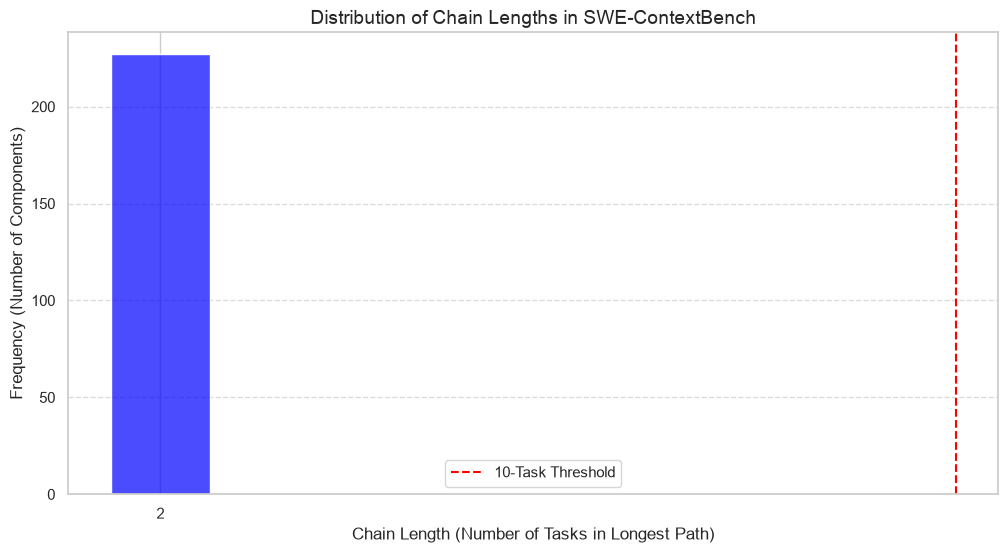

In [15]:
# 5. Plotting the Distribution
plt.figure(figsize=(12, 6))
sns.histplot(chain_lengths, bins=range(1, max(chain_lengths) + 2), discrete=True, color='blue', alpha=0.7)
plt.title('Distribution of Chain Lengths in SWE-ContextBench', fontsize=14)
plt.xlabel('Chain Length (Number of Tasks in Longest Path)', fontsize=12)
plt.ylabel('Frequency (Number of Components)', fontsize=12)

# Enhance x-axis ticks
max_val = max(chain_lengths) if chain_lengths else 10
plt.xticks(range(1, max_val + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axvline(x=10, color='red', linestyle='--', label='10-Task Threshold')
plt.legend()
plt.show()